# RNA sequencing II

<a href="?print-pdf">print view</a>  
<a href="RNAseq-II.ipynb" download>notebook</a>

# Today ... lets go through an example 

**Simple analysis of gene expression data from samples with healthy and apoptotic cells**

# Dataset
- **Gene expression count matrix for healthy vs apoptotic cells**

# RNA-Seq analysis

- **Input: gene expression count matrix for healthy vs apoptotic cells**
- **Analysis:**
    - **Quality control**
    - **Variance stabilization and normalization**
    - **Differential expression analysis**
    - **Result visualization**

In [64]:
import pandas as pd
gene_df = pd.read_csv('https://mscbio2025-2025.github.io/files/data.csv',index_col=0);
gene_df.head()

,healthy_1,healthy_2,healthy_3,healthy_4,healthy_5,healthy_6,healthy_7,healthy_8,healthy_9,healthy_10,...,apoptotic_11,apoptotic_12,apoptotic_13,apoptotic_14,apoptotic_15,apoptotic_16,apoptotic_17,apoptotic_18,apoptotic_19,apoptotic_20
GAPDH,23,20,13,21,14,16,13,17,17,25,...,16,14,29,20,27,21,20,26,14,10
ACTB,18,24,22,18,25,19,23,13,16,15,...,10,20,12,25,16,16,15,20,10,14
RPL13A,15,22,16,18,19,26,17,20,21,37,...,28,26,21,18,16,15,40,18,25,21
EEF1A1,33,16,16,7,28,22,17,24,17,23,...,34,19,13,23,15,17,26,22,18,28
HPRT1,22,29,17,16,26,29,16,13,14,17,...,24,16,23,16,28,14,17,20,23,23


# Quiz

- **How many samples are there**
- **How many genes are there**
- **How many healthy samples and how many apoptotic samples are there**

# Quality control and filtering
- **Essential steps to ensure that only high-quality is used for downstream analysis**
- **E.g., keep only those genes with at least 10 counts in at least 2 samples**

In [66]:
# Filtering
qc_filter = (gene_df > 10).sum(axis=1) >= 2
filtered_df = gene_df[qc_filter]

# QUIZ
- **Were any genes removed?**
    - **If no, why not**
    - **If yes, which ones**

# Normalization and variance stabilization

- **To ensure that observed differences in gene expression reflect true biological variation, rather than technical bias or noise.**
- **Normalization ensures that differences in normalized read counts reflect genuine differences in gene expression**
- **Stabilization ensures highly expressed genes do not dominate analyses as genes with higher expression have higher variance.**


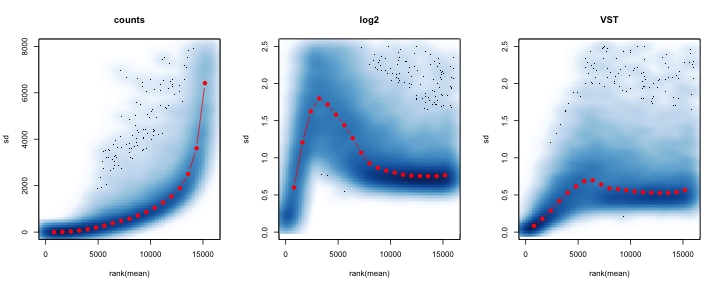

In [67]:
# Normalization and Variance Stabilization

# Counts per Million normalization (Better approach TMM -- next time)
cpm = filtered_df.div(filtered_df.sum(axis=0), axis=1) * 1e6

# Variance stabilization (Better approach VST -- next time)
log_cpm = np.log1p(cpm)

# 
log_cpm.head()


,healthy_1,healthy_2,healthy_3,healthy_4,healthy_5,healthy_6,healthy_7,healthy_8,healthy_9,healthy_10,...,apoptotic_11,apoptotic_12,apoptotic_13,apoptotic_14,apoptotic_15,apoptotic_16,apoptotic_17,apoptotic_18,apoptotic_19,apoptotic_20
GAPDH,10.815460,10.731331,10.258002,10.810320,10.268394,10.543120,10.198412,10.615662,10.613267,10.961359,...,9.830059,9.827904,10.549514,10.079074,10.462391,10.360278,10.140516,10.396554,9.806935,9.423614
ACTB,10.570343,10.913649,10.784081,10.656172,10.848197,10.714966,10.768941,10.347406,10.552644,10.450545,...,9.360087,10.184563,9.667162,10.302209,9.939163,10.088354,9.852847,10.134199,9.470484,9.760064
RPL13A,10.388027,10.826640,10.465635,10.656172,10.573766,11.028618,10.466667,10.778177,10.824571,11.353396,...,10.389651,10.446918,10.226751,9.973718,9.939163,10.023818,10.833643,10.028843,10.386729,10.165509
EEF1A1,11.176467,10.508193,10.465635,9.711748,10.961524,10.861567,10.466667,10.960496,10.613267,10.877979,...,10.583802,10.133272,9.747200,10.218831,9.874628,10.148976,10.402871,10.229506,10.058237,10.453182
HPRT1,10.771009,11.102888,10.526258,10.538392,10.887417,11.137816,10.406045,10.347406,10.419116,10.575705,...,10.235506,9.961429,10.317719,9.855941,10.498758,9.954828,9.978004,10.134199,10.303350,10.256478


In [68]:
# Differential Expression Testing
import numpy as np
from scipy.stats import nbinom, ttest_ind


# Generate label groupings
group_labels = np.array(["healthy"] * n_healthy + ["apoptotic"] * n_apoptotic)

# Check
pvals = []
logFC = []
for gene in filtered_df.index:
    grp_healthy = log_cpm.loc[gene, group_labels == "healthy"]
    grp_apoptotic = log_cpm.loc[gene, group_labels == "apoptotic"]
    t_stat, p = ttest_ind(grp_healthy, grp_apoptotic, equal_var=False)
    pvals.append(p)
    # Log2 fold change: apoptotic - healthy
    logFC.append(grp_apoptotic.mean() - grp_healthy.mean())


# P-value
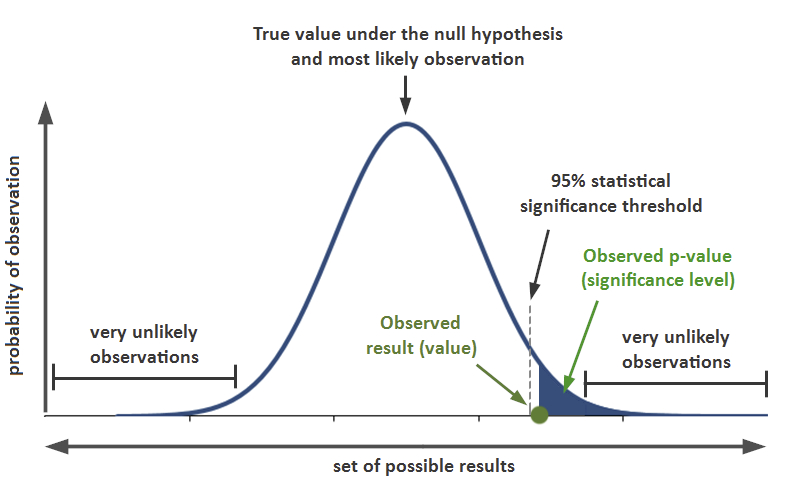

In [69]:
# Multiple testing correction (Benjamini-Hochberg FDR)

from statsmodels.stats.multitest import multipletests

adj_pvals = multipletests(pvals, method="fdr_bh")[1]

# Results
results = pd.DataFrame({
    "gene": filtered_df.index,
    "log2FC": logFC,
    "pval": pvals,
    "padj": adj_pvals
}).set_index("gene")
results.head(20)

,log2FC,pval,padj
gene,,,
GAPDH,-0.444492,1.282722e-04,0.000564
ACTB,-0.564394,4.491119e-06,0.000035
RPL13A,-0.629518,4.597034e-07,0.000010
EEF1A1,-0.500151,4.774840e-06,0.000035
HPRT1,-0.508990,2.328428e-05,0.000128
CASP3,0.095433,2.024409e-01,0.318121
CASP8,0.284745,8.543167e-04,0.002685
BAX,0.059504,5.758734e-01,0.603296
BCL2,0.219998,4.148730e-02,0.076060


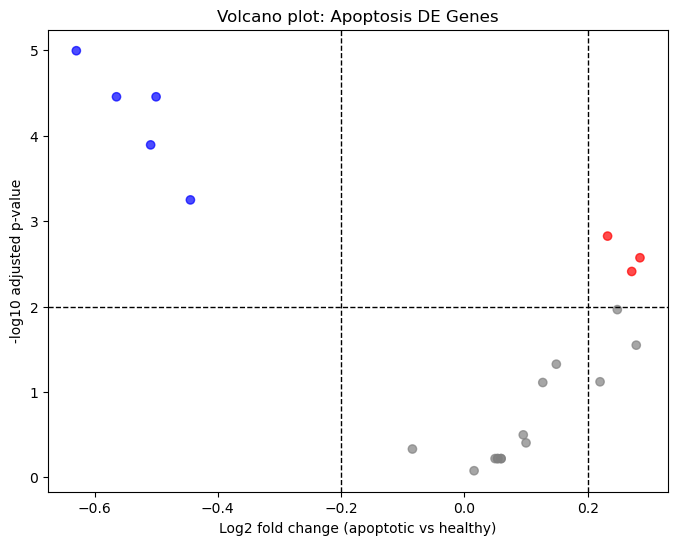

In [56]:
#  Volcano Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
colors = []
for idx, row in results.iterrows():
    if row["log2FC"] > 0.2 and row["padj"] < 0.01:
        colors.append("red")
    elif row["log2FC"] < -0.2 and row["padj"] < 0.01:
        colors.append("blue")
    else:
        colors.append("grey")
plt.scatter(results["log2FC"], -np.log10(results["padj"]), 
            c=colors, alpha=0.7)

# Dashed vertical lines at log2FC threshold
plt.axvline(x=0.2, color='black', linestyle='dashed', linewidth=1)
plt.axvline(x=-0.2, color='black', linestyle='dashed', linewidth=1)

# Dashed horizontal line at -log10(0.01)
plt.axhline(y=2, color='black', linestyle='dashed', linewidth=1)

plt.xlabel("Log2 fold change (apoptotic vs healthy)")
plt.ylabel("-log10 adjusted p-value")
plt.title("Volcano plot: Apoptosis DE Genes")
# optionally annotate significant genes as before
for gene in results.index:
    if abs(results.loc[gene, "log2FC"]) > 2 and results.loc[gene, "padj"] < 0.01:
        plt.text(results.loc[gene, "log2FC"], -np.log10(results.loc[gene, "padj"]), gene, fontsize=9)
plt.show()

Text(0.5, 1.05, 'Heatmap: Top 10 DE Genes')

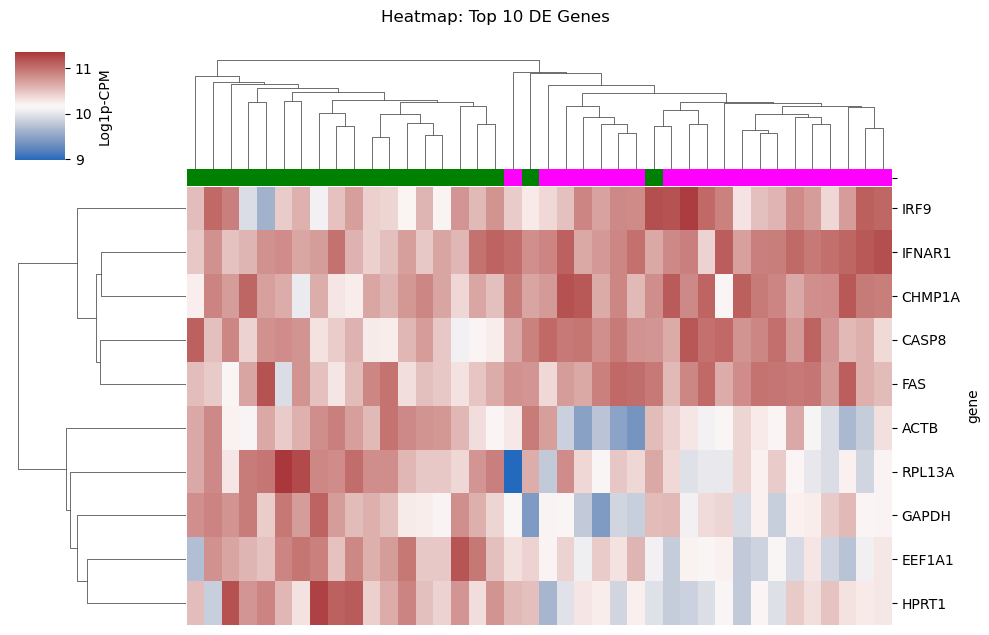

In [63]:
# Heatmap

import seaborn as sns

# healthy (green), apoptotic (magenta)
sample_type = pd.Series(["healthy"] * n_healthy + ["apoptotic"] * n_apoptotic, 
                        index=log_cpm.columns)
col_colors = sample_type.map({"healthy": "green", "apoptotic": "magenta"})

top_genes = results.sort_values("padj").head(10).index
data = log_cpm.loc[top_genes]

sns.clustermap(data, 
               cmap="vlag", 
               col_colors=col_colors,
               row_cluster=True,       # enable row clustering and dendrogram
               col_cluster=True,       # enable column clustering and dendrogram
               xticklabels=False, 
               yticklabels=top_genes,
               cbar_kws={"label": "Log1p-CPM"},
               figsize=(10, 6))
plt.suptitle("Heatmap: Top 10 DE Genes", y=1.05)


# Next time --> More RNA-Seq